In [1]:
print("Hello")

Hello


# load

In [2]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
) 

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 75441)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 70315)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 63036)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 55155)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 39854)

# #### Device() ####
# device = cuda:6

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:6)
# edge_attr                (32464, 16)              Tensor (cuda:6)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:6)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---

In [3]:
from modules.train import Loader
from modules.data import GraphDataset
import torch

In [4]:
def load_model(model, state_dict_path:str, device:str, dataset:GraphDataset|None=None, batch_size:int=128):
    # init with loader
    init_fn = getattr(model, 'init_with_loader', None)
    if callable(init_fn) and dataset is not None:
        loader = Loader(dataset, device=device, batch_size=batch_size)
        init_fn(loader)

    # load state dict
    state_dict = torch.load(state_dict_path, map_location=device)
    model.load_state_dict(state_dict)

    # set model to eval
    model.eval()    

---

In [5]:
from torch_geometric.loader import DataLoader
from modules.data import GraphDataset
from modules.utils import dict_summary
from collections import defaultdict
import pandas as pd

# typing
import torch
import torch.nn as nn
from torch import Tensor
from torch_geometric.data import Data, Batch


In [6]:
class ModelOut2():
    def __init__(self, model:nn.Module, dataset:GraphDataset, batch_size:int=64, **fwd_kwargs):
        fwd_kwargs = fwd_kwargs if fwd_kwargs is not None else {}

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        x_list = []
        y_list = []
        out_list = []

        for batch in loader:
            out = model(batch, **fwd_kwargs)
            out = self._detach_items(out)
            out_list.append(out)
            x_list.append(batch.x)
            y_list.append(batch.y)

        self.x = torch.cat(x_list, dim=0).reshape(-1, dataset.wrapper.num_nodes).cpu()
        self.y = torch.cat(y_list, dim=0).cpu()
        self.out = self._transpose_values(out_list)

    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple (recursive)
        if isinstance(item, (list, tuple, set)):
            return type(item)(self._detach_items(i) for i in item)

        # dict, PyG Data/DataBatch
        if isinstance(item, (dict, Data, Batch)):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # other class with .x
        if hasattr(item, 'x'):
            return {
                'x': self._detach_items(item.x),
                'y': self._detach_items(getattr(item, 'y', None)),
                'sample_id': self._detach_items(getattr(item, 'sample_id', None))
            }
        
        # fallback
        return item

    def _transpose_values(self, values) -> dict:
        out = defaultdict(list)

        # collect
        for v in values:
            for k, val in v.items():
                out[k].append(val)

        # concat if tensor
        for k, vals in out.items():
            v0 = vals[0]

            if torch.is_tensor(v0):
                if v0.ndim == 0: # scalar tensor -> stack
                    out[k] = torch.stack(vals, dim=0)

                # elif v0.ndim == 1: # vector tensor -> concat

                else: # batched tensor -> concat on batch dim
                    out[k] = torch.cat(vals, dim=0)
            
            elif isinstance(v0, dict): # dict -> recursively concat
                out[k] = self._transpose_values(vals)

            else:
                out[k] = vals

        return dict(out)

---

In [7]:
from modules.layers import AttentionSetPooling
from modules.model import MultiLatentModel
from modules.norm import LogCounts
from modules.train import MultiTrainer, MultiTrainerStage, Experiment, grid, Loader
from modules.trainers import ReconstrTrainer, ClassifTrainer
from modules.loss import NBLoss, KLDLoss, MultiLoss

import torch
import torch.nn as nn
from functools import partial

# multihead model
model = MultiLatentModel(
    dataset = dataset,
    embed_dim = 128,
    # head_dim = None (default)
    # num_heads = 1 (default)
    method = 'set',

    # layers
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = AttentionSetPooling,
    mlp = False,
    variational = True,
    # out_module = nn.Linear (default)

    # layer params
    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer', 
    end_fn = False,

    # kwargs
    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
    # pooling_kwargs = None (default)
)

load_model(
    model=model,
    state_dict_path='output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/pathway_vae_trial_0_model.pth',
    device=device,
    dataset=dataset,
)

vals = ModelOut2(model, dataset, need_weights=True)

# viz

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
print(dict_summary(vals.out))

# x                        (1172, 4373)             Tensor (cpu)
# x_t                      (1172, 4373)             Tensor (cpu)
# libsize                  (1172,)                  Tensor (cpu)
# libscale                 (19,)                    Tensor (cpu)
# batch_size               19                       list
# num_nodes                19                       list
# layer_outs               6                        dict
# h_node                   (1172, 4373, 128)        Tensor (cpu)
# h_pool                   (1172, 305, 128)         Tensor (cpu)
# theta                    (19, 4373)               Tensor (cpu)
# z_mu_ae                  (1172, 128)              Tensor (cpu)
# z_logvar_ae              (1172, 128)              Tensor (cpu)
# z_ae                     (1172, 128)              Tensor (cpu)
# z_mu_cl                  (1172, 128)              Tensor (cpu)
# z_logvar_cl              (1172, 128)              Tensor (cpu)
# z_cl                     (1172, 128)           

In [10]:
print(dict_summary(vals.out['layer_outs']))

# ne                       0                        dict
# np                       1                        dict
# lp_ae                    1                        dict
# lp_cl                    1                        dict
# out_ae                   0                        dict
# out_cl                   0                        dict



In [11]:
attn_np = vals.out['layer_outs']['np']['attn']
print(attn_np.shape)

torch.Size([1172, 4373, 305])


In [12]:
attn_np.sum(dim=1).unique()

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])

In [13]:
attn_lp_ae = vals.out['layer_outs']['lp_ae']['attn'].squeeze() # 1172,305,1 -> 1172,305
print(attn_lp_ae.shape)

torch.Size([1172, 305])


In [14]:
attn_lp_ae.sum(dim=1).unique()

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [15]:
attn_lp_cl = vals.out['layer_outs']['lp_cl']['attn'].squeeze() # 1172,305,1 -> 1172,305
print(attn_lp_cl.shape)

torch.Size([1172, 305])


In [16]:
# elementwise product to get joint attention
attn_joint_ae = attn_lp_ae.unsqueeze(1) * attn_np
attn_joint_cl = attn_lp_cl.unsqueeze(1) * attn_np
print(attn_joint_ae.shape)

torch.Size([1172, 4373, 305])


---

In [17]:
attn_joint_ae.mean(dim=0).sum(dim=1)

tensor([6.0922e-06, 1.1514e-04, 8.8717e-05,  ..., 3.8733e-05, 5.5621e-05,
        1.5205e-05])

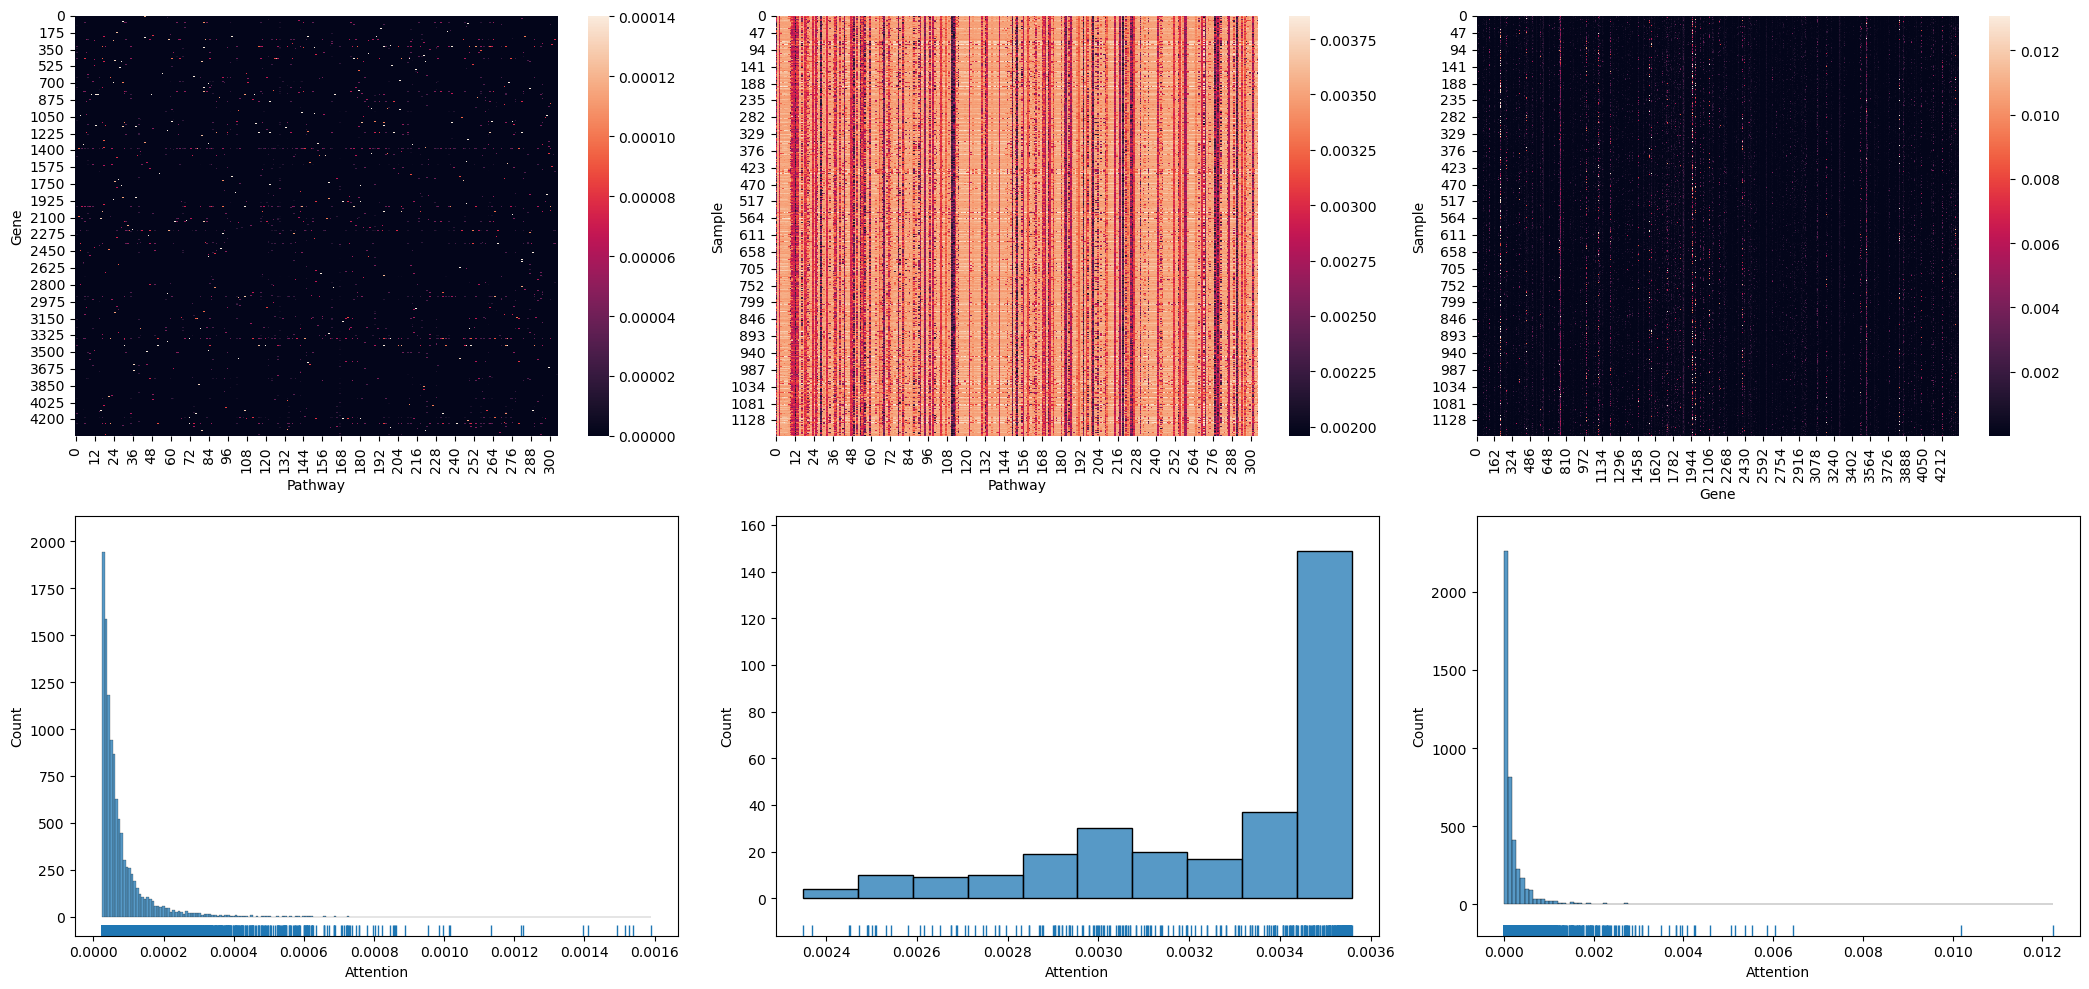

In [45]:
data = attn_joint_ae
alpha = 0.001
xmin=0

fig, ax = plt.subplots(2,3,figsize=(21,10))

x = data.mean(dim=0)
xmin = 0.000025
xflat = x.flatten()
xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,0])
sns.rugplot(xflat, ax=ax[1,0], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,0]).set(ylim=-100)

x = data.sum(dim=1)
xmin = 0.001
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,1])
sns.rugplot(xflat, ax=ax[1,1], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,1]).set(ylim=-16)

x = data.sum(dim=2)
xmin = 0.005
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,2])
sns.rugplot(xflat, ax=ax[1,2], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,2]).set(ylim=-200)

ax[1,0].set_xlabel('Attention')
ax[1,1].set_xlabel('Attention')
ax[1,2].set_xlabel('Attention')


ax[0,0].set_xlabel('Pathway')
ax[0,1].set_xlabel('Pathway')
ax[0,2].set_xlabel('Gene')

ax[0,0].set_ylabel('Gene')
ax[0,1].set_ylabel('Sample')
ax[0,2].set_ylabel('Sample')

plt.tight_layout()
plt.show()


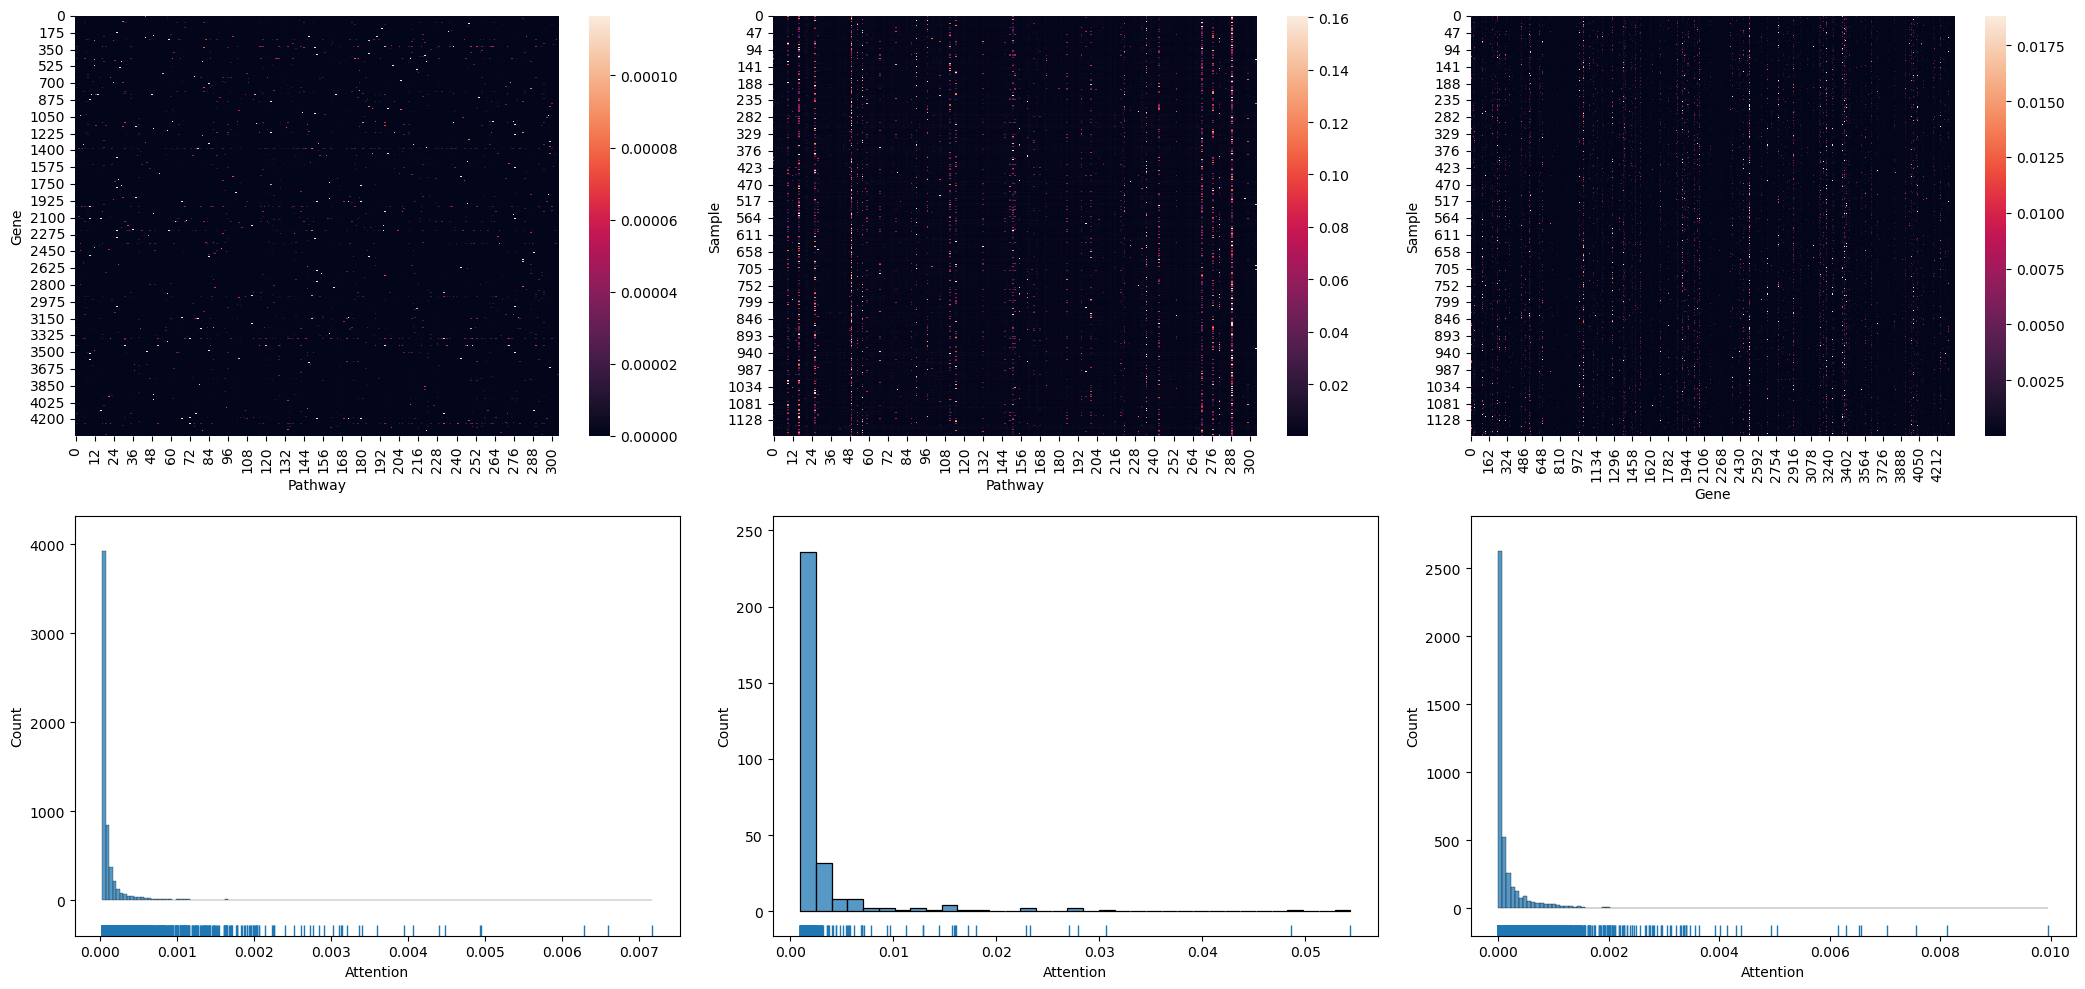

In [46]:
data = attn_joint_cl
alpha = 0.001
xmin=0

fig, ax = plt.subplots(2,3,figsize=(21,10))

x = data.mean(dim=0)
xmin = 0.000025
xflat = x.flatten()
xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,0])
sns.rugplot(xflat, ax=ax[1,0], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,0]).set(ylim=-400)

x = data.sum(dim=1)
xmin = 0.001
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,1])
sns.rugplot(xflat, ax=ax[1,1], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,1]).set(ylim=-16)

x = data.sum(dim=2)
xmin = 0.005
xflat = x.mean(dim=0).flatten()
# xflat = xflat[xflat > xmin]
xmax = x.quantile(1-alpha)
sns.heatmap(x, vmax=xmax, ax=ax[0,2])
sns.rugplot(xflat, ax=ax[1,2], lw=0.5)#, height=-.02, clip_on=False)
sns.histplot(xflat, ax=ax[1,2]).set(ylim=-200)

ax[1,0].set_xlabel('Attention')
ax[1,1].set_xlabel('Attention')
ax[1,2].set_xlabel('Attention')


ax[0,0].set_xlabel('Pathway')
ax[0,1].set_xlabel('Pathway')
ax[0,2].set_xlabel('Gene')

ax[0,0].set_ylabel('Gene')
ax[0,1].set_ylabel('Sample')
ax[0,2].set_ylabel('Sample')

plt.tight_layout()
plt.show()


---

<Axes: >

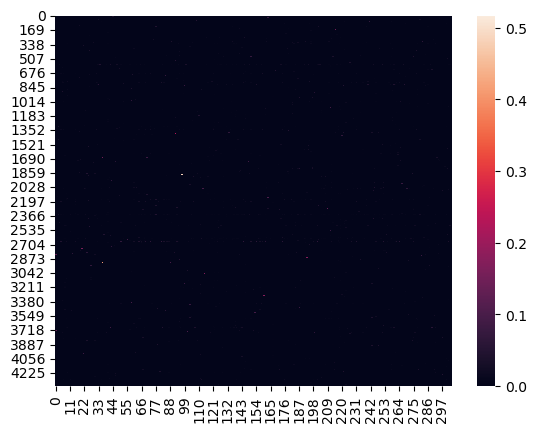

In [20]:
# mean attn_np
# size is (num_genes, num_pathways)
sns.heatmap(attn_np.mean(dim=0))#, vmax=attn_np.mean(dim=0).quantile(0.995))


<Axes: >

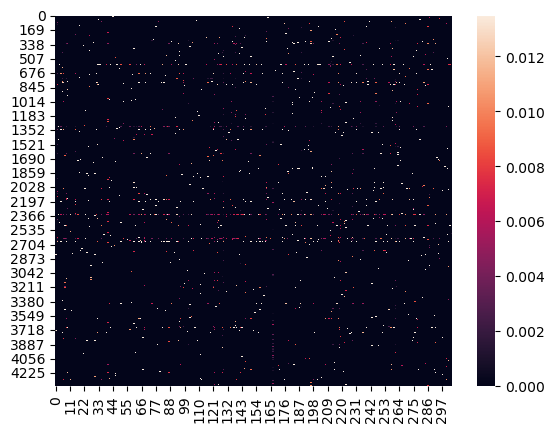

In [21]:
sns.heatmap(attn_np.mean(dim=0), vmax=attn_np.mean(dim=0).quantile(0.995))

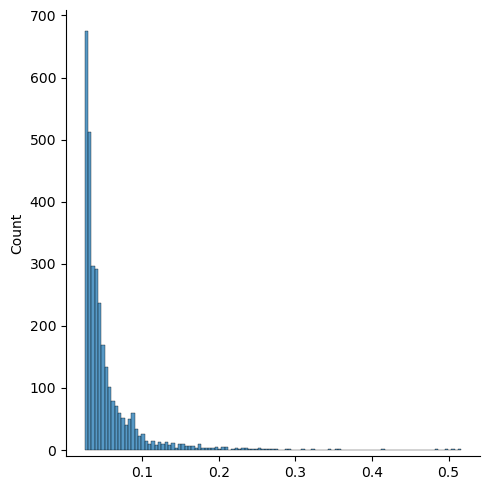

In [22]:
x = attn_np.mean(dim=0).view(-1)    
ax = sns.displot(x[x > 0.025]).set(ylim=-10)

In [23]:
# pathway importance across samples (mean across genes)
# size is (samples, pathways)
# sns.heatmap(attn_np.mean(dim=1), vmax=attn_np.mean(dim=1).quantile(0.90))
# this provides no valuable info; all values sum to 1 (mean to 0.0002) due to softmax

In [24]:
# x = attn_np.mean(dim=1).view(-1)
# print(x.shape)
# sns.displot(x)

<Axes: >

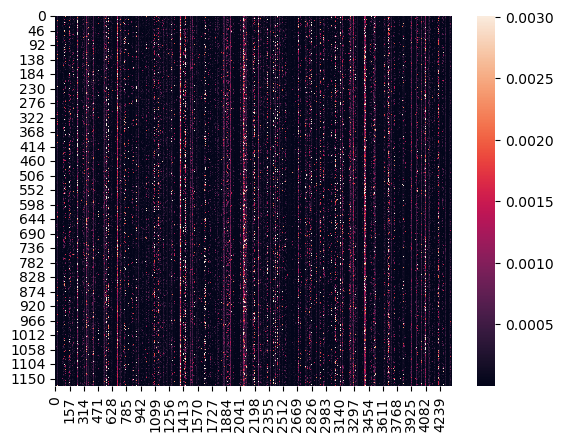

In [25]:
# gene importance across samples (mean across pathways)
# size is (samples, genes)
sns.heatmap(attn_np.mean(dim=2), vmax=attn_np.mean(dim=2).quantile(0.99))

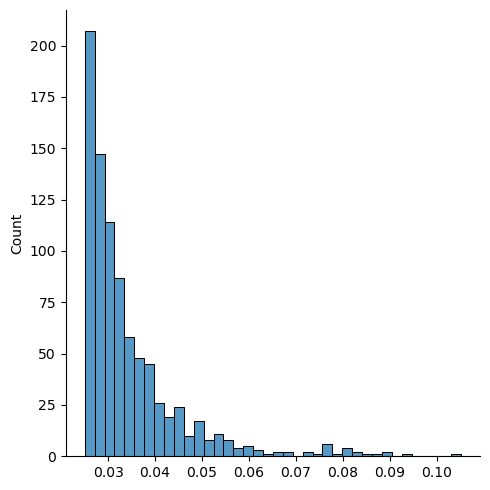

In [26]:
x = attn_np.mean(dim=2).view(-1)
sns.displot(x[x > 0.025])

---

<Axes: >

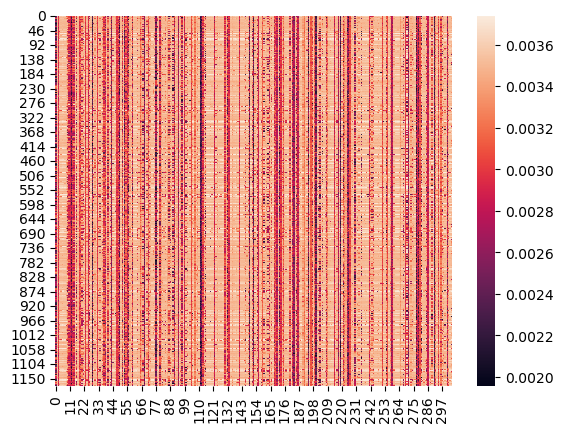

In [27]:
sns.heatmap(attn_lp_ae, vmax=attn_lp_ae.quantile(0.99))

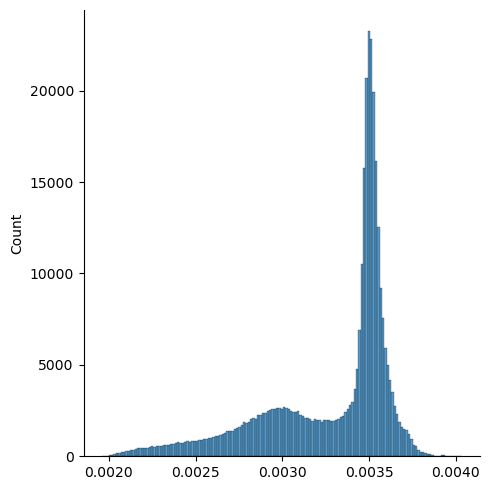

In [28]:
sns.displot(attn_lp_ae.view(-1))

<Axes: >

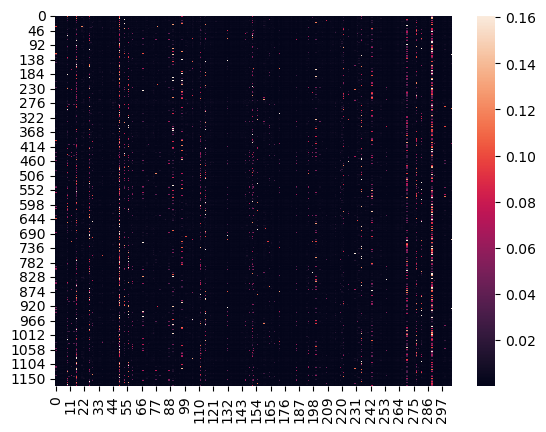

In [29]:
sns.heatmap(attn_lp_cl, vmax=attn_lp_cl.quantile(0.999))

In [30]:
attn_lp_cl.shape

torch.Size([1172, 305])

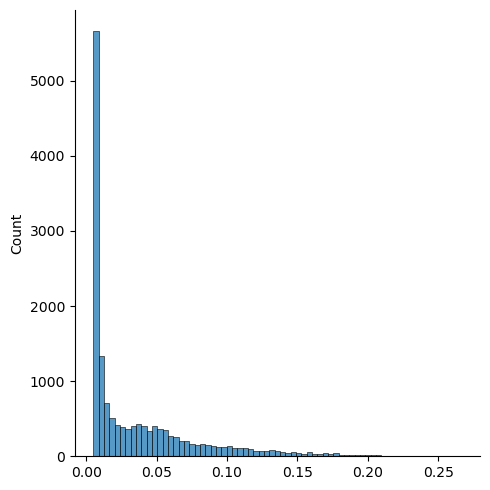

In [31]:
x = attn_lp_cl.view(-1)
sns.displot(x[x > 0.005])

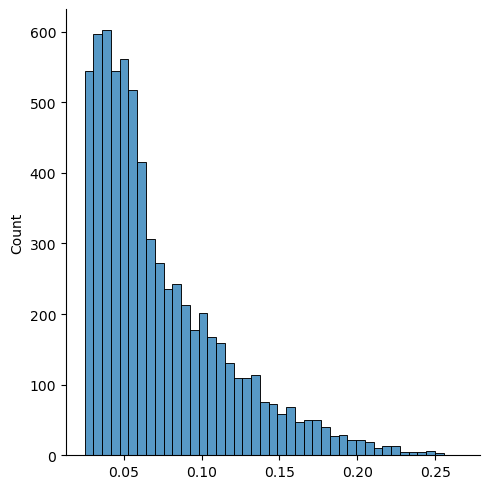

In [32]:
x = attn_lp_cl.view(-1)
sns.displot(x[x > 0.025])

---

In [33]:
def split_by_class(x, cls, as_df:bool=True, col_names:list|None=None):
    out = {int(c): x[cls == c].mean(dim=0).tolist() for c in cls.unique()}
    out['Total'] = x.mean(dim=0).tolist()

    if as_df:
        out = pd.DataFrame(out)
        if col_names is not None:
            out.columns = col_names

    return out

In [34]:
col_names = dataset.wrapper.y_labels + ['Total']

class_lp_ae = split_by_class(attn_lp_ae, vals.y, col_names=col_names)
class_lp_cl = split_by_class(attn_lp_cl, vals.y, col_names=col_names)

In [47]:
class_lp_ae

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
0,0.002514,0.002580,0.002729,0.002736,0.002761,0.002687
1,0.003507,0.003504,0.003532,0.003519,0.003576,0.003528
2,0.002894,0.002930,0.002967,0.002921,0.002894,0.002937
3,0.003497,0.003490,0.003520,0.003499,0.003596,0.003517
4,0.003506,0.003506,0.003524,0.003514,0.003599,0.003525
...,...,...,...,...,...,...
300,0.003495,0.003491,0.003534,0.003502,0.003566,0.003522
301,0.002645,0.002710,0.002857,0.002707,0.002517,0.002752
302,0.003506,0.003492,0.003374,0.003475,0.003436,0.003428
303,0.003503,0.003499,0.003552,0.003514,0.003605,0.003538


In [48]:
class_lp_cl

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
0,0.007475,0.006024,0.004043,0.002651,0.029587,0.006973
1,0.001640,0.002547,0.001926,0.002805,0.000695,0.001960
2,0.000673,0.001134,0.001030,0.001372,0.000345,0.000972
3,0.001633,0.002906,0.002032,0.003293,0.000706,0.002123
4,0.001552,0.002860,0.001905,0.002798,0.000691,0.001955
...,...,...,...,...,...,...
300,0.001115,0.001830,0.001513,0.002125,0.000515,0.001481
301,0.000791,0.001274,0.001107,0.001477,0.000619,0.001085
302,0.001474,0.002278,0.001662,0.002424,0.000638,0.001711
303,0.001620,0.002618,0.002107,0.002928,0.000724,0.002074


---

In [36]:
import pandas as pd
pnames = pd.read_csv(dataset_dir/'other'/'pathway_names.csv')

In [37]:
pnames

,entry,name
0,hsa01100,Metabolic pathways - Homo sapiens (human)
1,hsa01200,Carbon metabolism - Homo sapiens (human)
2,hsa01210,2-Oxocarboxylic acid metabolism - Homo sapiens...
3,hsa01212,Fatty acid metabolism - Homo sapiens (human)
4,hsa01230,Biosynthesis of amino acids - Homo sapiens (hu...
...,...,...
361,hsa04934,Cushing syndrome - Homo sapiens (human)
362,hsa01521,EGFR tyrosine kinase inhibitor resistance - Ho...
363,hsa01524,Platinum drug resistance - Homo sapiens (human)
364,hsa01523,Antifolate resistance - Homo sapiens (human)


In [38]:
plabels = [s.replace('path:', '') for s in dataset.wrapper.pathway_labels]

In [39]:
plabels

['hsa04975',
 'hsa04010',
 'hsa04630',
 'hsa05030',
 'hsa05210',
 'hsa04137',
 'hsa05169',
 'hsa04114',
 'hsa05205',
 'hsa04520',
 'hsa05320',
 'hsa04666',
 'hsa00280',
 'hsa04672',
 'hsa05330',
 'hsa04068',
 'hsa05412',
 'hsa04668',
 'hsa00520',
 'hsa04061',
 'hsa00750',
 'hsa00563',
 'hsa05321',
 'hsa04613',
 'hsa00592',
 'hsa04979',
 'hsa04340',
 'hsa00240',
 'hsa04614',
 'hsa00030',
 'hsa00565',
 'hsa05222',
 'hsa04934',
 'hsa04911',
 'hsa04976',
 'hsa05417',
 'hsa04122',
 'hsa00630',
 'hsa00440',
 'hsa04915',
 'hsa04360',
 'hsa04371',
 'hsa05110',
 'hsa03018',
 'hsa00100',
 'hsa00670',
 'hsa00330',
 'hsa05031',
 'hsa05322',
 'hsa04512',
 'hsa05034',
 'hsa04964',
 'hsa04622',
 'hsa05150',
 'hsa00400',
 'hsa04978',
 'hsa04610',
 'hsa04072',
 'hsa00760',
 'hsa04740',
 'hsa04910',
 'hsa05016',
 'hsa04714',
 'hsa05203',
 'hsa05226',
 'hsa04916',
 'hsa04012',
 'hsa00980',
 'hsa04015',
 'hsa05212',
 'hsa00920',
 'hsa05332',
 'hsa01523',
 'hsa05213',
 'hsa04723',
 'hsa04612',
 'hsa04213',

In [40]:
pnames

,entry,name
0,hsa01100,Metabolic pathways - Homo sapiens (human)
1,hsa01200,Carbon metabolism - Homo sapiens (human)
2,hsa01210,2-Oxocarboxylic acid metabolism - Homo sapiens...
3,hsa01212,Fatty acid metabolism - Homo sapiens (human)
4,hsa01230,Biosynthesis of amino acids - Homo sapiens (hu...
...,...,...
361,hsa04934,Cushing syndrome - Homo sapiens (human)
362,hsa01521,EGFR tyrosine kinase inhibitor resistance - Ho...
363,hsa01524,Platinum drug resistance - Homo sapiens (human)
364,hsa01523,Antifolate resistance - Homo sapiens (human)


In [41]:
pathway_names = pnames.set_index('entry').loc[plabels, 'name'].to_list()
pathway_names = [s.replace(' - Homo sapiens (human)', '') for s in pathway_names]

In [55]:
class_lp_ae.index = pathway_names
class_lp_ae.sort_values(by='Solid Tissue Normal', ascending=False)

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
Rheumatoid arthritis,0.003395,0.003137,0.003210,0.003125,0.003692,0.003267
Salmonella infection,0.003509,0.003501,0.003585,0.003517,0.003622,0.003558
Efferocytosis,0.003505,0.003503,0.003583,0.003518,0.003618,0.003556
Pyrimidine metabolism,0.003500,0.003488,0.003562,0.003501,0.003616,0.003541
Cellular senescence,0.003507,0.003501,0.003583,0.003517,0.003616,0.003556
...,...,...,...,...,...,...
Renin-angiotensin system,0.002387,0.002551,0.002548,0.002497,0.002306,0.002489
Drug metabolism - cytochrome P450,0.002439,0.002540,0.002589,0.002586,0.002303,0.002532
Rap1 signaling pathway,0.002406,0.002609,0.002662,0.002659,0.002294,0.002579
Aldosterone-regulated sodium reabsorption,0.002538,0.002795,0.002663,0.002666,0.002281,0.002615


In [53]:
class_lp_cl.index = pathway_names
class_lp_cl.sort_values(by='Total', ascending=False)

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
ECM-receptor interaction,0.068290,0.032837,0.060636,0.040646,0.039647,0.054389
Hypertrophic cardiomyopathy,0.050079,0.075654,0.054519,0.032238,0.027151,0.048639
Arrhythmogenic right ventricular cardiomyopathy,0.047924,0.021097,0.033414,0.013964,0.024553,0.030668
Hedgehog signaling pathway,0.004496,0.004825,0.045591,0.013503,0.022616,0.027894
Rheumatoid arthritis,0.032757,0.034302,0.024939,0.029217,0.018914,0.027090
...,...,...,...,...,...,...
Intestinal immune network for IgA production,0.000661,0.001116,0.001040,0.001376,0.000344,0.000974
Fc gamma R-mediated phagocytosis,0.000669,0.001127,0.001035,0.001373,0.000352,0.000974
Neutrophil extracellular trap formation,0.000667,0.001122,0.001037,0.001374,0.000344,0.000974
JAK-STAT signaling pathway,0.000673,0.001134,0.001030,0.001372,0.000345,0.000972


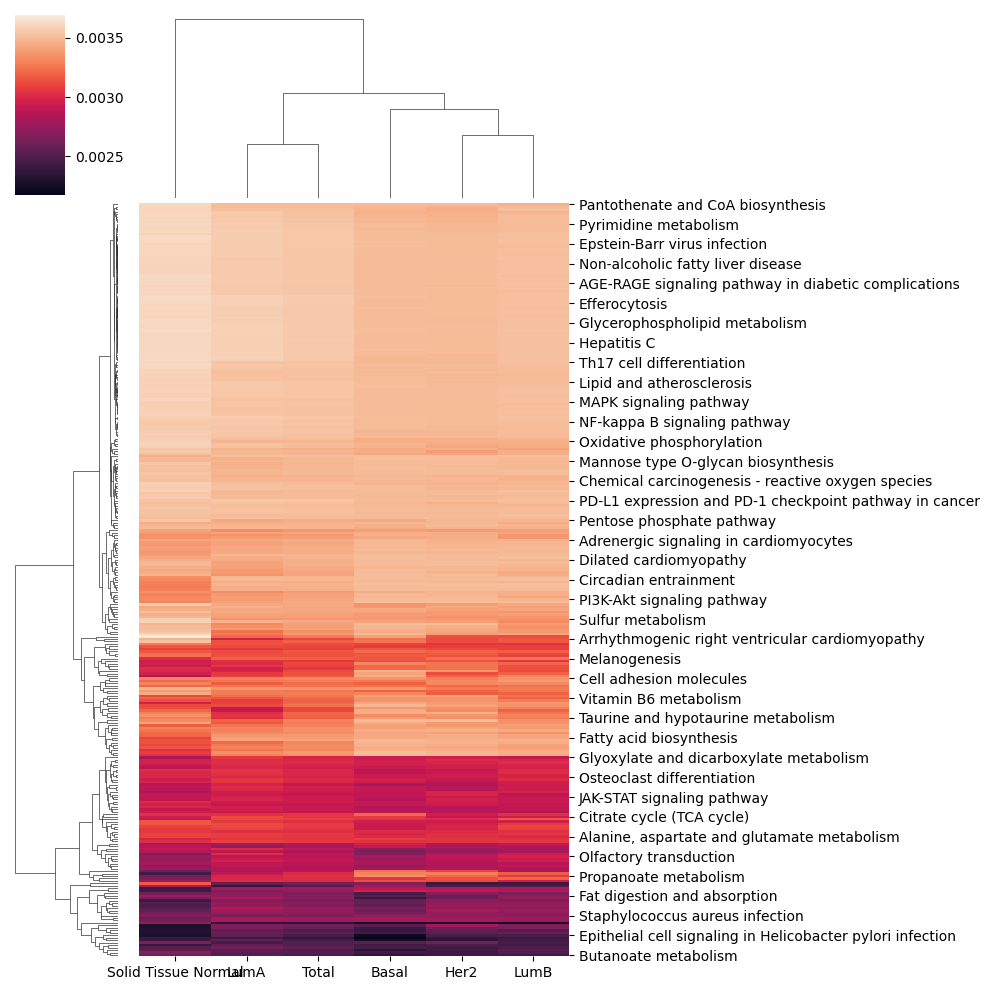

In [65]:
sns.clustermap(class_lp_ae)

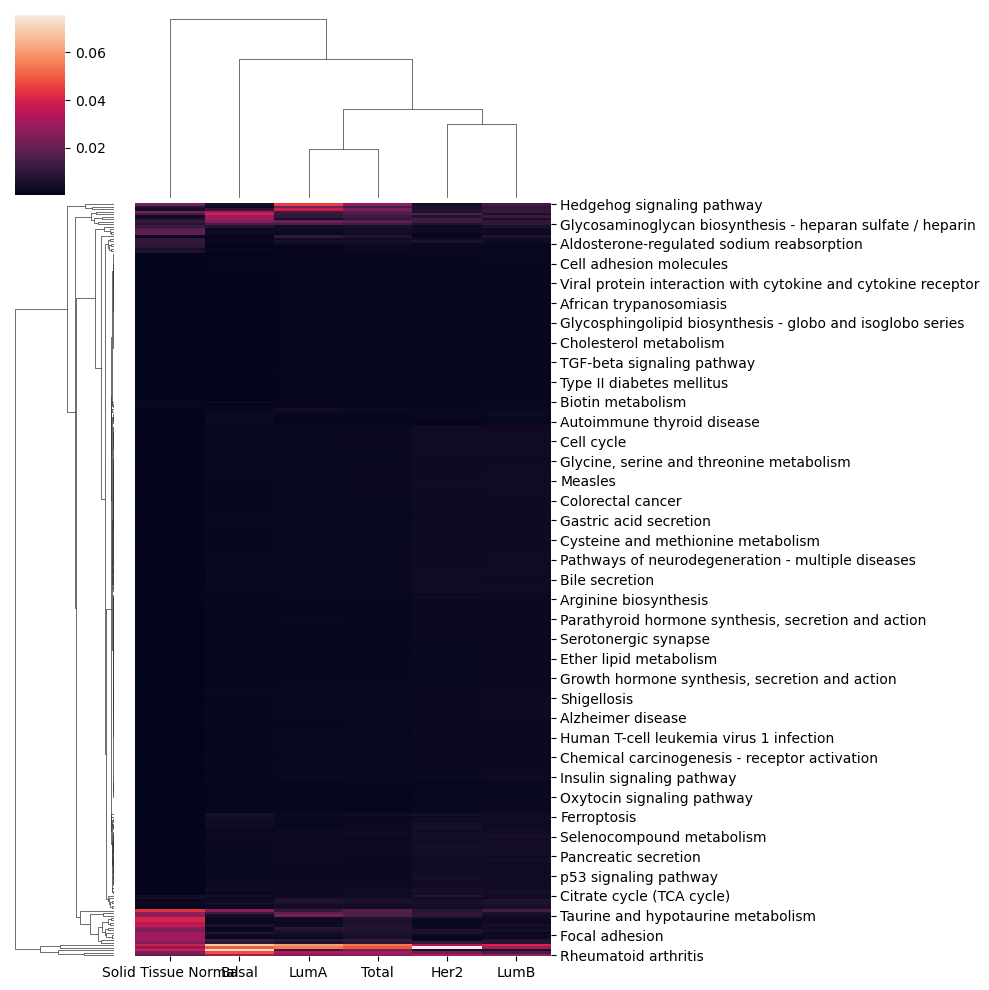

In [64]:
sns.clustermap(class_lp_cl)

---

In [ ]:
def split_by_class(x, cls):
    out = {int(c): x[cls == c].mean(dim=0).mean(dim=1).tolist() for c in cls.unique()}
    out['Total'] = x.mean(dim=0).mean(dim=1).tolist()
    return out

In [66]:
n2s = split_by_class(class_lp_cl, vals.y)
n2s

KeyError: "None of [Index([False, False, False, False, False, False,  True, False, False,  True,\n       ...\n       False, False, False, False,  True,  True, False, False, False, False],\n      dtype='bool', length=1172)] are in the [columns]"

In [ ]:
# sns.heatmap(n2s[0], vmax=0.01)

In [ ]:
n2s = pd.DataFrame(n2s)
n2s.columns = dataset.wrapper.y_labels + ['Total']
n2s.index = dataset.wrapper.x_labels
n2s

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
FGR,0.000006,0.000003,0.000005,0.000010,2.049418e-06,0.000006
GCLC,0.000125,0.000141,0.000140,0.000129,1.087491e-04,0.000133
NFYA,0.000036,0.000045,0.000092,0.000025,2.471953e-04,0.000083
SEMA3F,0.000040,0.000022,0.000016,0.000014,2.984571e-05,0.000022
CFTR,0.000326,0.000435,0.000688,0.000802,2.412561e-04,0.000587
...,...,...,...,...,...,...
ZNF229,0.000003,0.000006,0.000013,0.000011,2.900591e-07,0.000009
ACACA,0.000360,0.000283,0.000428,0.000320,4.004735e-04,0.000385
H3C10,0.000017,0.000010,0.000033,0.000009,1.459163e-04,0.000035
ADORA3,0.000056,0.000062,0.000061,0.000062,6.685468e-05,0.000061


In [ ]:
n2s.sort_values(by='Total', ascending=False)

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
MAPK3,1.487299e-02,1.334179e-02,1.176753e-02,8.122340e-03,9.773011e-03,1.155732e-02
ADCY9,1.330261e-02,1.478544e-02,7.987767e-03,6.548245e-03,1.463156e-02,9.740603e-03
IKBKB,7.721215e-03,6.953026e-03,5.154619e-03,5.588340e-03,7.967246e-03,6.060390e-03
CASP9,4.580769e-03,4.954348e-03,6.324078e-03,5.332729e-03,4.729090e-03,5.604645e-03
MAPK8,3.847665e-03,7.502446e-03,6.348857e-03,5.417753e-03,3.368176e-03,5.555719e-03
...,...,...,...,...,...,...
ZNF530,1.026705e-06,1.583353e-07,1.170640e-06,7.002527e-07,4.789818e-07,9.250491e-07
ZNF641,1.343838e-06,3.009497e-06,6.267551e-07,4.047257e-07,2.670158e-07,8.397205e-07
ZNF184,7.646915e-07,3.766084e-07,8.727145e-07,3.834096e-07,1.644970e-06,8.070480e-07
ZFP90,1.636320e-06,1.039294e-06,5.443512e-07,5.648720e-07,3.079282e-07,7.433924e-07


/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


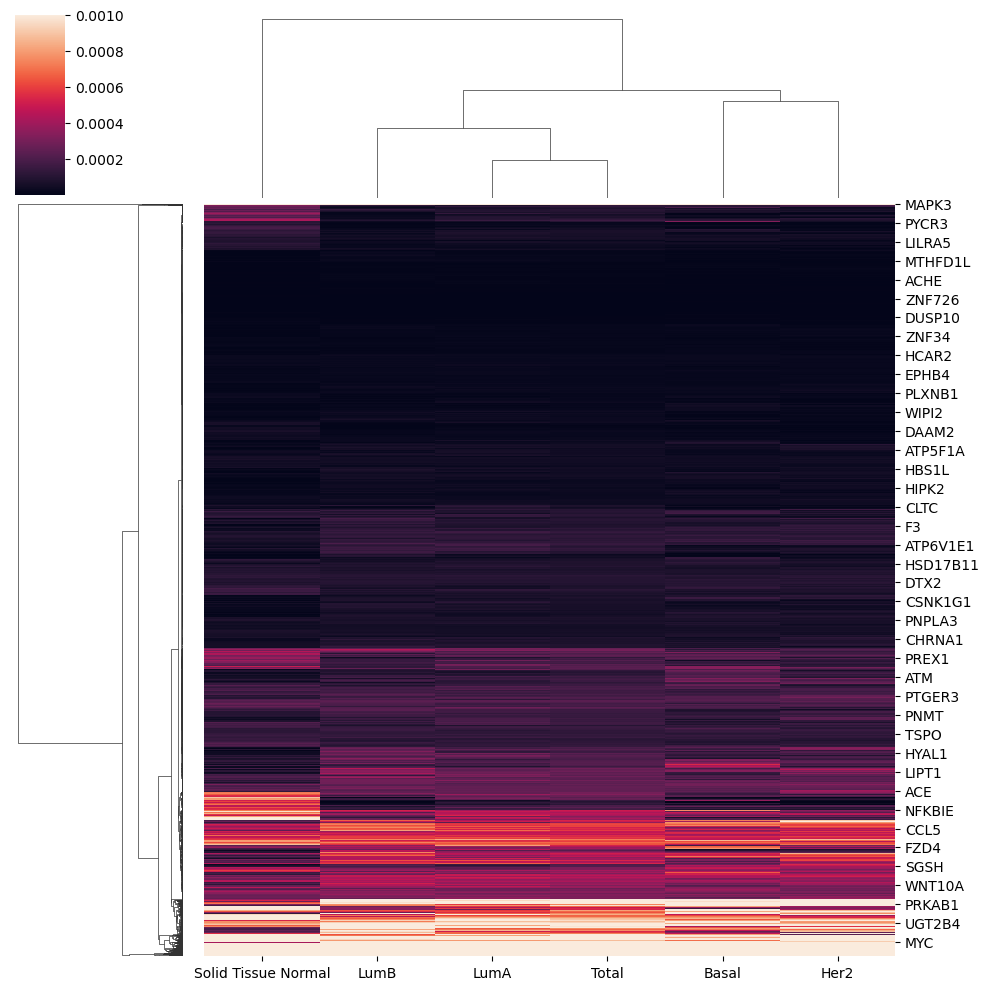

In [ ]:
sns.clustermap(n2s, vmax=0.001)

In [ ]:
dataset.wrapper.x_labels


['FGR',
 'GCLC',
 'NFYA',
 'SEMA3F',
 'CFTR',
 'CYP51A1',
 'KRIT1',
 'BAD',
 'LAP3',
 'AOC1',
 'M6PR',
 'CYP26B1',
 'ALS2',
 'CASP10',
 'CFLAR',
 'MTMR7',
 'SARM1',
 'AK2',
 'CD38',
 'KDM1A',
 'CAMKK1',
 'NDUFAB1',
 'PDK4',
 'CDC27',
 'HCCS',
 'DVL2',
 'UPF1',
 'SLC25A5',
 'DHX33',
 'ACSM3',
 'PRKAR2B',
 'CREBBP',
 'KMT2E',
 'ZNF195',
 'ITGAL',
 'PDK2',
 'ITGA3',
 'LAMP2',
 'ITGA2B',
 'MAP3K14',
 'ABCC8',
 'AP2B1',
 'CX3CL1',
 'CACNA1G',
 'TNFRSF12A',
 'MAP3K9',
 'RALA',
 'AGK',
 'ALDH3B1',
 'FARP2',
 'GGCT',
 'TBXA2R',
 'COX10',
 'VPS41',
 'SCIN',
 'PNPLA4',
 'ADIPOR2',
 'PAFAH1B1',
 'DNAH9',
 'MATK',
 'CD79B',
 'RHBDF1',
 'CACNA2D2',
 'TEAD3',
 'SELE',
 'FMO3',
 'MYLIP',
 'NOX1',
 'E2F2',
 'PSMB1',
 'NADK',
 'CYTH3',
 'AASS',
 'MGST1',
 'ST3GAL1',
 'MMP25',
 'MAPK8IP2',
 'MASP2',
 'POMT2',
 'VTA1',
 'MLXIPL',
 'UQCRC1',
 'GIPR',
 'SEMA3G',
 'STAB1',
 'IDS',
 'ZNF200',
 'CD4',
 'BTK',
 'HFE',
 'FYN',
 'FMO1',
 'LYPLA2',
 'MRC2',
 'ABHD5',
 'PIK3C2A',
 'PLAUR',
 'DCN',
 'PPP5C',
 'MAP4